# Historical Olympic Games Analysis (1896–2016)
---

## Introduction 
__Introduction to the topic__ 

The modern Olympic Games represent the pinnacle of international athletic competition, evolving from a modest revival in Athens in 1896 with fewer than 250 male athletes into a global multi-sport spectacle featuring over 11,000 competitors across Summer and Winter editions. Over more than a century of historical competition, the Games have served as a reflection of geopolitical shifts, changing socio-economic landscapes, expanding athletic participation, and evolving sports science.

This analysis leverages historical data on Olympic athletes, participation records, physical attributes (age, height, weight), and medal achievements to evaluate the key structural patterns that govern Olympic performance. By examining data spanning from 1896 through 2016, this report provides empirical insights into demographic trends, biomechanical baselines, regional dominance, national delegation efficiency, age dynamics, and strategic sport specialization.

---

## Problem Statement

Despite a century of Olympic competition, winning medals remains heavily concentrated, the top 10 countries hold  **60.80%** of all historical medals, with top-performing teams converting up to **33.76%** of their entries into medals compared to less than **15%** globally. National Olympic Committees and sports leaders lack clear, data-driven facts to guide funding and athlete development. Governing bodies struggle to evaluate progress in gender equality (growing from **0%** in 1896 to **45%** in 2016), map out body-type requirements (**162 cm** in Gymnastics vs. **192 cm** in Basketball), and set target age ranges (**18–23** in Swimming vs. **30s–40s** in Shooting). They also lack clear evidence on whether to fund many different sports or focus deeply on a single sport (where specialized teams earn up to **99.36%** of their medals in one event). Without these answers, leaders risk wasting money and steering talented athletes into the wrong sports.

## Objectives:
__Questions that will guide the analysis to solve the problem__


1. **Gender Participation Trends**: How has male vs. female athlete participation evolved across Summer and Winter Olympic Games from 1896 to 2016?
2. **Geographic Concentration**: Which nations dominate historical medal tallies, and how concentrated are medals among top-performing regions?
3. **Biomechanical Baselines**: How do physical attributes (Height and Weight) vary across distinct sports, and do medalists differ physically from non-medalists?
4. **Medal Conversion Efficiency**: Which major participant nations achieve the highest medal conversion rate per athlete entry?
5. **Age Dynamics & Peak Windows**: What are the peak age distributions across youth-dominated sports (e.g., Gymnastics, Swimming) versus veteran-dominated sports (e.g., Shooting, Equestrianism)?
6. **National Sport Specialization**: Which nations exhibit hyper-specialization by winning a dominant share of their total historical medals within a single sport?

---

## Exploratory Data Analysis (EDA):

### Data Info:
__Getting the data and exploring it (includes descriptive statistics)__

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df_events = pd.read_csv('athlete_events.csv')
df_noc = pd.read_csv('noc_regions.csv')

In [13]:
df_events

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,City,Sport,Event,Medal
0,1,A Dijiang,male,24.0,180.0cm,80.0kg,China,CHN,1992 Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,Male,23.0,170.0cm,60.0kg,China,CHN,2012 Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,Male,24.0,NaN,NaN,Denmark,DEN,1920 Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,FeMale,21.0,185.0cm,82.0kg,Netherlands,NED,1988 Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0cm,89.0kg,Poland-1,POL,1976 Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,male,27.0,176.0cm,59.0kg,Poland,POL,2014 Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,Male,27.0,176.0cm,59.0kg,Poland,POL,2014 Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,male,30.0,185.0cm,96.0kg,Poland,POL,1998 Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN


In [14]:
df_events.info()

<class 'pandas.DataFrame'>
RangeIndex: 271116 entries, 0 to 271115
Data columns (total 13 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   ID      271116 non-null  int64  
 1   Name    271116 non-null  str    
 2   Sex     271116 non-null  str    
 3   Age     261642 non-null  float64
 4   Height  210945 non-null  str    
 5   Weight  208241 non-null  str    
 6   Team    271116 non-null  str    
 7   NOC     271116 non-null  str    
 8   Games   271116 non-null  str    
 9   City    271116 non-null  str    
 10  Sport   271116 non-null  str    
 11  Event   271116 non-null  str    
 12  Medal   39783 non-null   str    
dtypes: float64(1), int64(1), str(11)
memory usage: 54.2 MB


In [15]:
df_events.isnull().sum()

ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

In [16]:
df_events[['Age']].describe()

,Age
count,261642.000000
mean,25.556898
std,6.393561
min,10.000000
25%,21.000000
50%,24.000000
75%,28.000000
max,97.000000


In [17]:
df_events[['Height']].describe()

,Height
count,210945
unique,95
top,180.0cm
freq,12492


In [18]:
df_events[['Weight']].describe()

,Weight
count,208241
unique,220
top,70.0kg
freq,9625


In [19]:
df_events['Sport'].nunique()


66

In [20]:
df_events['Event'].nunique()

765

In [21]:
df_events['Team'].nunique()

1184

In [22]:
df_events['Medal'].value_counts(dropna=False)

Medal
NaN       231333
Gold       13372
Bronze     13295
Silver     13116
Name: count, dtype: int64

In [23]:
df_noc.info()

<class 'pandas.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   NOC     230 non-null    str  
 1   region  227 non-null    str  
 2   notes   21 non-null     str  
dtypes: str(3)
memory usage: 8.4 KB


In [24]:
df_noc.isnull().sum()

NOC         0
region      3
notes     209
dtype: int64

### Data Handling: 
__Cleaning, transforming, and combining data__

In [25]:
df_clean = df_events.copy()
df_clean['Sex'] = df_clean['Sex'].str.strip().str.capitalize().replace({'Female': 'F', 'Male': 'M'})
df_clean

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0cm,80.0kg,China,CHN,1992 Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0cm,60.0kg,China,CHN,2012 Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0cm,82.0kg,Netherlands,NED,1988 Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0cm,89.0kg,Poland-1,POL,1976 Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN
271112,135570,Piotr ya,M,27.0,176.0cm,59.0kg,Poland,POL,2014 Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN
271113,135570,Piotr ya,M,27.0,176.0cm,59.0kg,Poland,POL,2014 Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0cm,96.0kg,Poland,POL,1998 Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN


In [26]:
df_clean['Height'] = pd.to_numeric(df_clean['Height'].astype(str).str.replace('cm', '').str.strip())
df_clean['Weight'] = pd.to_numeric(df_clean['Weight'].astype(str).str.replace('kg', '').str.strip())

In [27]:
df_clean[['Sex', 'Height', 'Weight']].dtypes

Sex           str
Height    float64
Weight    float64
dtype: object

In [28]:
df_clean['Year'] = df_clean['Games'].str.extract(r'(\d{4})').astype(int)

In [29]:
df_clean['Season'] = df_clean['Games'].str.extract(r'([A-Za-z]+)')

In [30]:
df_clean['Has_Medal'] = df_clean['Medal'].notnull().astype(int)

In [31]:
df_clean[['Games', 'Year', 'Season', 'Has_Medal']].head()

,Games,Year,Season,Has_Medal
0,1992 Summer,1992,Summer,0
1,2012 Summer,2012,Summer,0
2,1920 Summer,1920,Summer,0
3,1900 Summer,1900,Summer,1
4,1988 Winter,1988,Winter,0


In [32]:
df_merged = pd.merge(df_clean, df_noc[['NOC', 'region']], on='NOC', how='left')
df_merged

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,City,Sport,Event,Medal,Year,Season,Has_Medal,region
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,1992,Summer,0,China
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,2012,Summer,0,China
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,Antwerpen,Football,Football Men's Football,NaN,1920,Summer,0,Denmark
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,1900,Summer,1,Denmark
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,1988,Winter,0,Netherlands
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN,1976,Winter,0,Poland
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN,2014,Winter,0,Poland
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN,2014,Winter,0,Poland
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN,1998,Winter,0,Poland


In [33]:
df_merged['region'] = df_merged['region'].fillna(df_merged['NOC'])

In [34]:
df_merged[['Name', 'NOC', 'region', 'Sport']].head()

,Name,NOC,region,Sport
0,A Dijiang,CHN,China,Basketball
1,A Lamusi,CHN,China,Judo
2,Gunnar Nielsen Aaby,DEN,Denmark,Football
3,Edgar Lindenau Aabye,DEN,Denmark,Tug-Of-War
4,Christine Jacoba Aaftink,NED,Netherlands,Speed Skating


In [121]:
df_merged = df_merged.drop_duplicates()
df_merged

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,City,Sport,Event,Medal,Year,Season,Has_Medal,region
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,1992,Summer,0,China
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,2012,Summer,0,China
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,Antwerpen,Football,Football Men's Football,NaN,1920,Summer,0,Denmark
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,1900,Summer,1,Denmark
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,1988,Winter,0,Netherlands
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271111,135569,Andrzej ya,M,29.0,179.0,89.0,Poland-1,POL,1976 Winter,Innsbruck,Luge,Luge Mixed (Men)'s Doubles,NaN,1976,Winter,0,Poland
271112,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Individual",NaN,2014,Winter,0,Poland
271113,135570,Piotr ya,M,27.0,176.0,59.0,Poland,POL,2014 Winter,Sochi,Ski Jumping,"Ski Jumping Men's Large Hill, Team",NaN,2014,Winter,0,Poland
271114,135571,Tomasz Ireneusz ya,M,30.0,185.0,96.0,Poland,POL,1998 Winter,Nagano,Bobsleigh,Bobsleigh Men's Four,NaN,1998,Winter,0,Poland


In [122]:
df_merged.isnull().sum()

ID                0
Name              0
Sex               0
Age            9315
Height        58814
Weight        61527
Team              0
NOC               0
Games             0
City              0
Sport             0
Event             0
Medal        229959
Year              0
Season            0
Has_Medal         0
region            0
dtype: int64

In [123]:
df_merged.info()

<class 'pandas.DataFrame'>
Index: 269731 entries, 0 to 271115
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   ID         269731 non-null  int64  
 1   Name       269731 non-null  str    
 2   Sex        269731 non-null  str    
 3   Age        260416 non-null  float64
 4   Height     210917 non-null  float64
 5   Weight     208204 non-null  float64
 6   Team       269731 non-null  str    
 7   NOC        269731 non-null  str    
 8   Games      269731 non-null  str    
 9   City       269731 non-null  str    
 10  Sport      269731 non-null  str    
 11  Event      269731 non-null  str    
 12  Medal      39772 non-null   str    
 13  Year       269731 non-null  int64  
 14  Season     269731 non-null  str    
 15  Has_Medal  269731 non-null  int64  
 16  region     269731 non-null  str    
dtypes: float64(3), int64(3), str(11)
memory usage: 64.5 MB


In [124]:
df_merged.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,City,Sport,Event,Medal,Year,Season,Has_Medal,region
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN,1992,Summer,0,China
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,London,Judo,Judo Men's Extra-Lightweight,NaN,2012,Summer,0,China
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,Antwerpen,Football,Football Men's Football,NaN,1920,Summer,0,Denmark
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold,1900,Summer,1,Denmark
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN,1988,Winter,0,Netherlands


In [126]:
df_merged = df_merged.drop_duplicates()

In [127]:
df_merged.to_csv('olympics_cleaned_data.csv', index=False)

### Analysis: 
__Answering the objectives through data analysis__



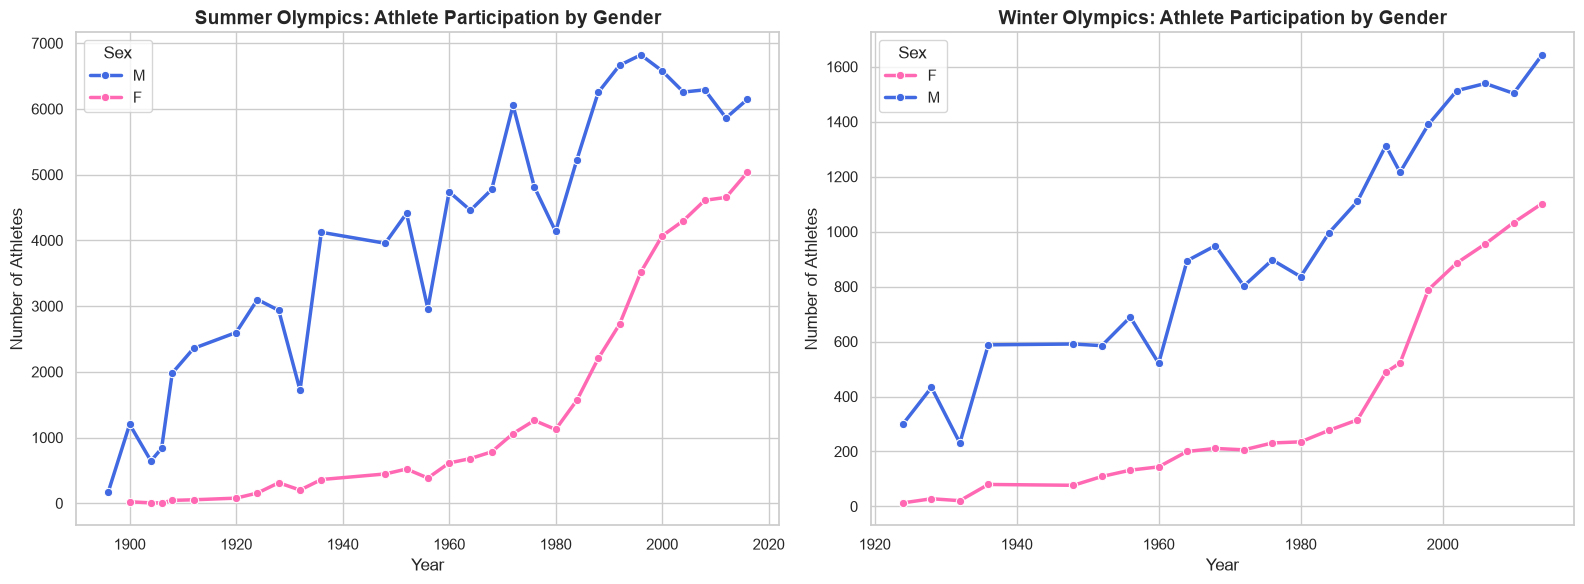

In [96]:
part_gender = df_merged.groupby(['Year', 'Season', 'Sex'])['ID'].nunique().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.lineplot(data=part_gender[part_gender['Season'] == 'Summer'], x='Year', y='ID', hue='Sex', marker='o', ax=axes[0],palette={'M': 'royalblue', 'F': 'hotpink'}, linewidth=2.5)
axes[0].set_title('Summer Olympics: Athlete Participation by Gender', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=12)
axes[0].set_ylabel('Number of Athletes', fontsize=12)

sns.lineplot(data=part_gender[part_gender['Season'] == 'Winter'], x='Year', y='ID', hue='Sex', marker='o', ax=axes[1],palette={'M': 'royalblue', 'F': 'hotpink'}, linewidth=2.5)
axes[1].set_title('Winter Olympics: Athlete Participation by Gender', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=12)
axes[1].set_ylabel('Number of Athletes', fontsize=12)

plt.tight_layout()
plt.show()

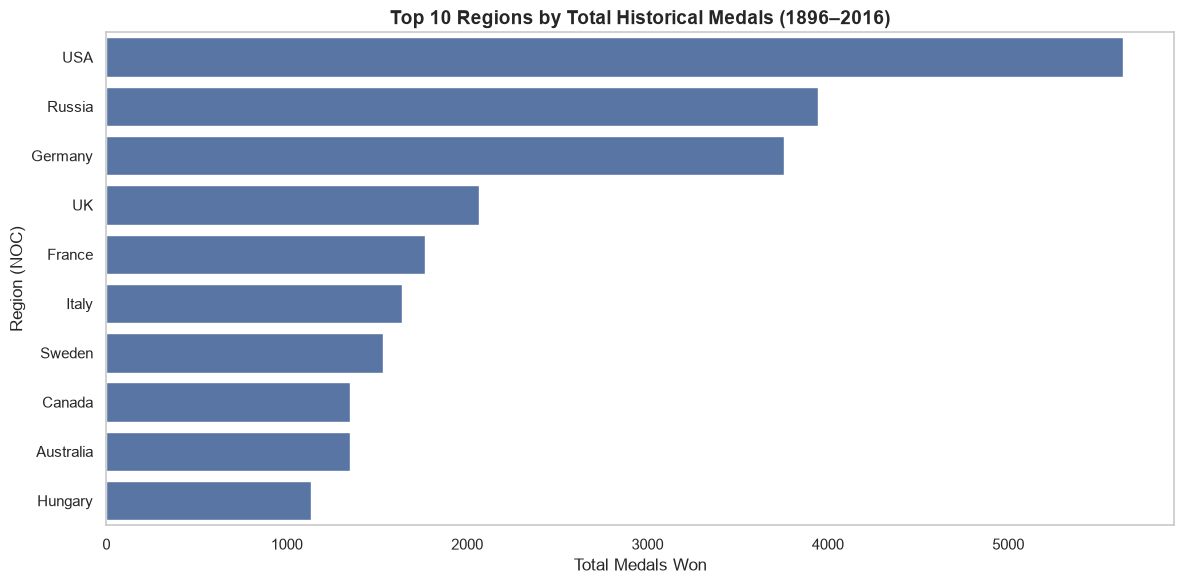

In [81]:
top_medals = (df_merged[df_merged['Has_Medal'] == 1].groupby('region')['Medal'].count().reset_index().sort_values(by='Medal', ascending=False))

plt.figure(figsize=(12, 6))
sns.barplot(data=top_medals.head(10), x='Medal', y='region' )
plt.grid(False)
plt.title('Top 10 Regions by Total Historical Medals (1896–2016)', fontsize=14, fontweight='bold')
plt.xlabel('Total Medals Won', fontsize=12)
plt.ylabel('Region (NOC)', fontsize=12)
plt.tight_layout()
plt.show()

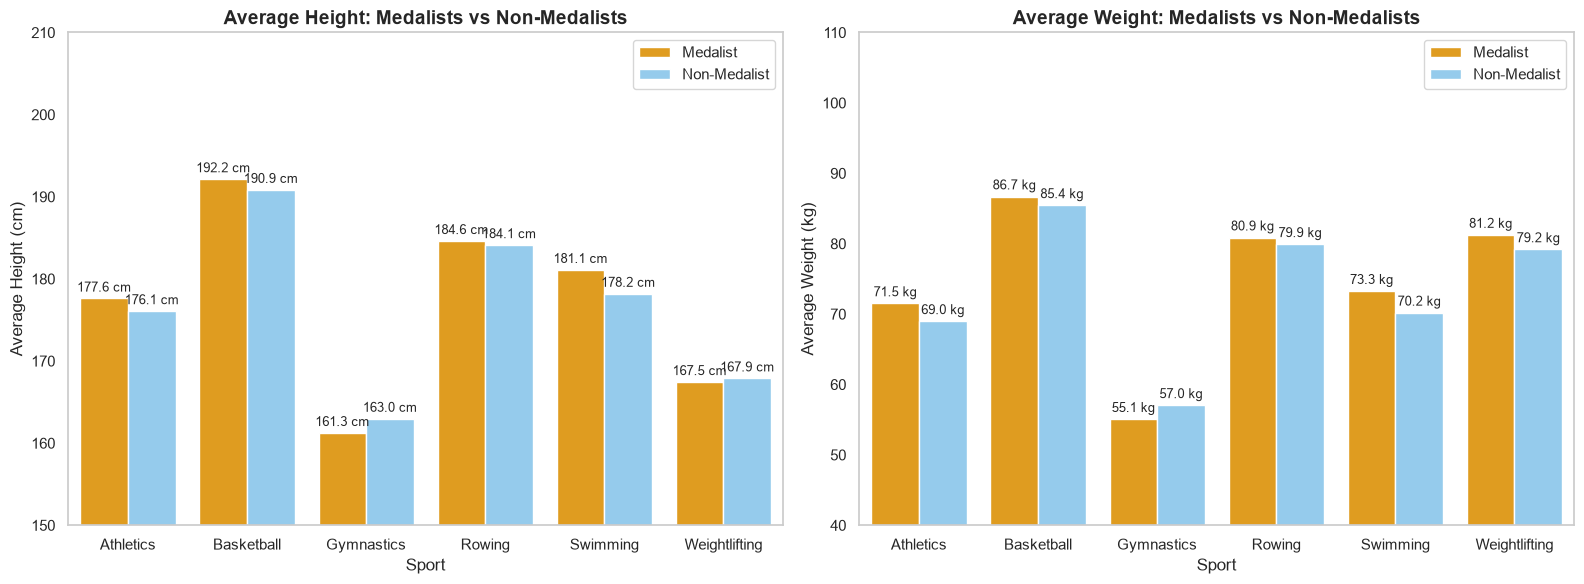

In [110]:
sports_list = ['Basketball', 'Gymnastics', 'Swimming', 'Athletics', 'Weightlifting', 'Rowing']
df_phys = df_merged[df_merged['Sport'].isin(sports_list) & df_merged['Height'].notnull() & df_merged['Weight'].notnull()].copy()
df_phys['Status'] = df_phys['Has_Medal'].map({0: 'Non-Medalist', 1: 'Medalist'})
phys_avg = df_phys.groupby(['Sport', 'Status'])[['Height', 'Weight']].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


bar1 = sns.barplot( data=phys_avg, x='Sport', y='Height', hue='Status',ax=axes[0], palette={'Non-Medalist': 'lightskyblue', 'Medalist': 'orange'})
axes[0].set_title('Average Height: Medalists vs Non-Medalists', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Average Height (cm)', fontsize=12)
axes[0].set_xlabel('Sport', fontsize=12)
axes[0].set_ylim(150, 210) 
axes[0].legend(title="")

for container in bar1.containers:
    bar1.bar_label(container, fmt='%.1f cm', padding=3, fontsize=9)

bar2 = sns.barplot(data=phys_avg, x='Sport', y='Weight', hue='Status',ax=axes[1], palette={'Non-Medalist': 'lightskyblue', 'Medalist': 'orange'})
axes[1].set_title('Average Weight: Medalists vs Non-Medalists', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Weight (kg)', fontsize=12)
axes[1].set_xlabel('Sport', fontsize=12)
axes[1].set_ylim(40, 110)
axes[1].legend(title="")

for container in bar2.containers:
    bar2.bar_label(container, fmt='%.1f kg', padding=3, fontsize=9)

for ax in axes:
    ax.grid(False)
    

plt.tight_layout()
plt.show()

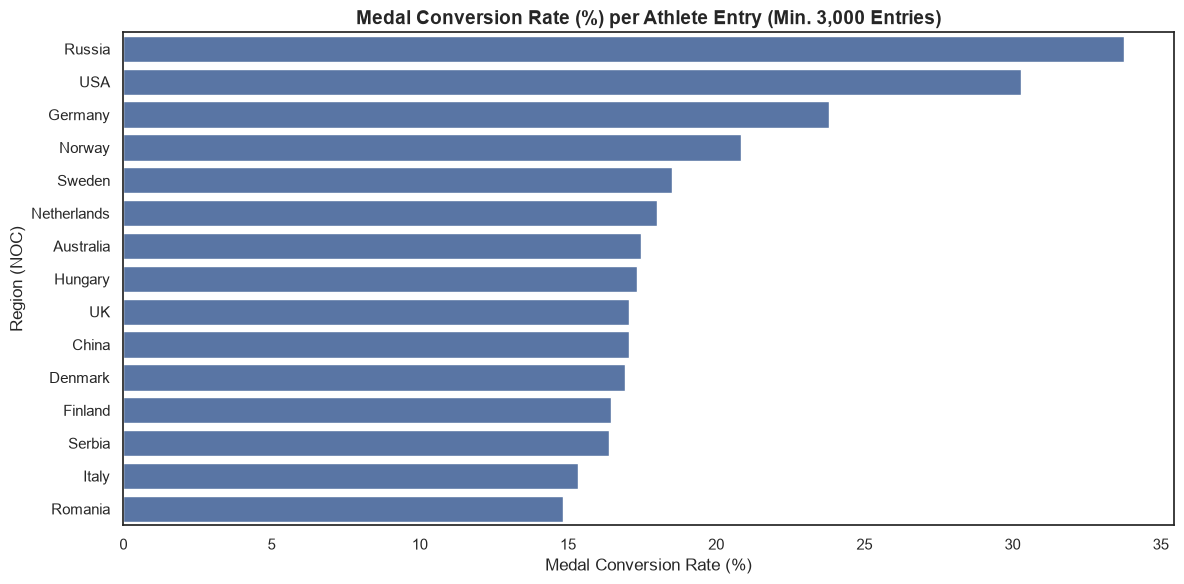

In [87]:

nation_efficiency = df_merged.groupby('region').agg(Total_Entries=('ID', 'count'),Total_Medals=('Has_Medal', 'sum'),Unique_Athletes=('ID', 'nunique')).reset_index()


nation_efficiency = nation_efficiency[nation_efficiency['Total_Entries'] >= 3000].copy()
nation_efficiency['Conversion_Rate_%'] = (nation_efficiency['Total_Medals'] / nation_efficiency['Total_Entries']) * 100

top_efficient = nation_efficiency.sort_values(by='Conversion_Rate_%', ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_efficient.head(15), x='Conversion_Rate_%', y='region')
plt.grid(False)
plt.title('Medal Conversion Rate (%) per Athlete Entry (Min. 3,000 Entries)', fontsize=14, fontweight='bold')
plt.xlabel('Medal Conversion Rate (%)', fontsize=12)
plt.ylabel('Region (NOC)', fontsize=12)
plt.tight_layout()
plt.show()

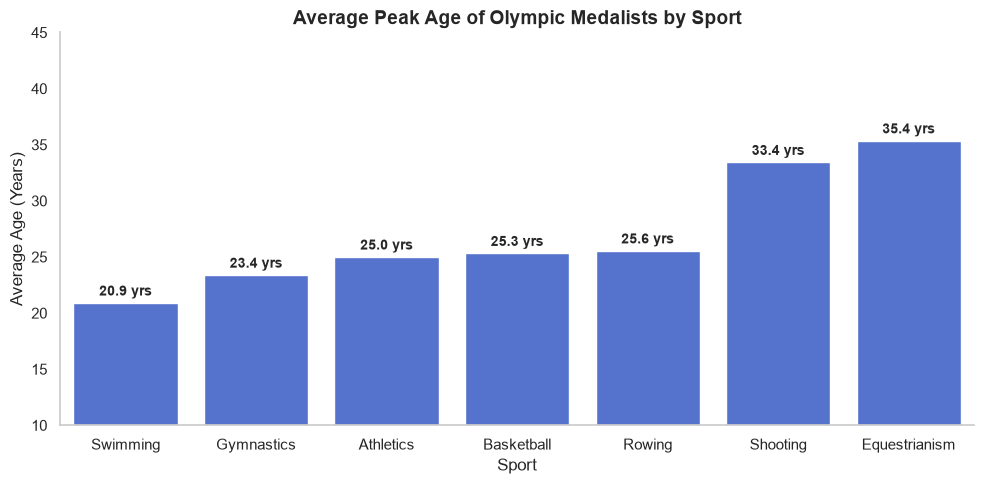

In [111]:
age_sports = ['Gymnastics', 'Swimming', 'Athletics', 'Basketball', 'Rowing', 'Shooting', 'Equestrianism']
df_medalists = df_merged[(df_merged['Sport'].isin(age_sports)) & (df_merged['Has_Medal'] == 1) & (df_merged['Age'].notnull())].copy()

age_avg = df_medalists.groupby('Sport')['Age'].mean().reset_index()
age_avg = age_avg.sort_values(by='Age', ascending=True)

plt.figure(figsize=(10, 5))


bar_plot = sns.barplot(data=age_avg, x='Sport', y='Age',color='royalblue')

for container in bar_plot.containers:
    bar_plot.bar_label(container, fmt='%.1f yrs', padding=3, fontsize=10, fontweight='bold')

plt.title('Average Peak Age of Olympic Medalists by Sport', fontsize=14, fontweight='bold')
plt.xlabel('Sport', fontsize=12)
plt.ylabel('Average Age (Years)', fontsize=12)
plt.ylim(10, 45)  
plt.grid(False)
sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

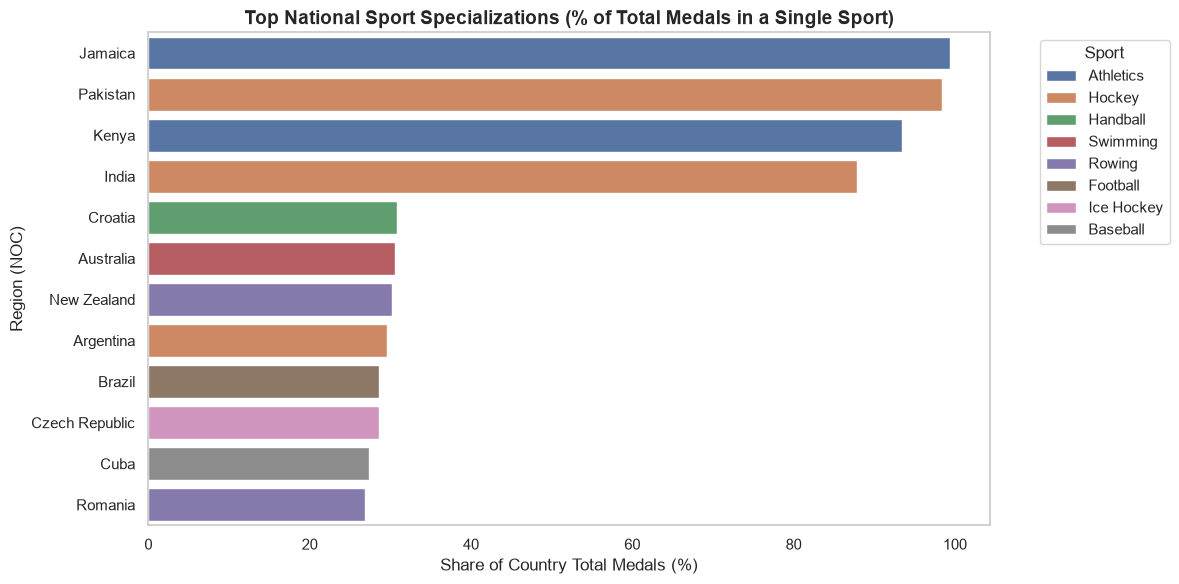

In [113]:
medals_only = df_merged[df_merged['Has_Medal'] == 1]
country_total = medals_only.groupby('region')['Medal'].count().reset_index(name='Country_Total')
sport_country = medals_only.groupby(['region', 'Sport'])['Medal'].count().reset_index(name='Sport_Medals')

spec_df = pd.merge(sport_country, country_total, on='region')
spec_df['Sport_Share_%'] = (spec_df['Sport_Medals'] / spec_df['Country_Total']) * 100


top_spec = spec_df[spec_df['Country_Total'] >= 100].sort_values(by='Sport_Share_%', ascending=False).head(12)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_spec, x='Sport_Share_%', y='region', hue='Sport')
plt.title('Top National Sport Specializations (% of Total Medals in a Single Sport)', fontsize=14, fontweight='bold')
plt.xlabel('Share of Country Total Medals (%)', fontsize=12)
plt.ylabel('Region (NOC)', fontsize=12)
plt.grid(False)
plt.legend(title='Sport', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [53]:

top10_regions = top_medals.head(10)['region'].tolist()

summary_table = df_merged[df_merged['region'].isin(top10_regions)].groupby('region').agg(
    Total_Athlete_Entries=('ID', 'count'),
    Unique_Athletes=('ID', 'nunique'),
    Total_Medals_Won=('Has_Medal', 'sum'),
    Gold_Medals=('Medal', lambda x: (x == 'Gold').sum()),
    Silver_Medals=('Medal', lambda x: (x == 'Silver').sum()),
    Bronze_Medals=('Medal', lambda x: (x == 'Bronze').sum()),
    Avg_Age=('Age', 'mean'),
    Avg_Height_cm=('Height', 'mean'),
    Avg_Weight_kg=('Weight', 'mean')
).reset_index()

summary_table['Conversion_Rate_%'] = (summary_table['Total_Medals_Won'] / summary_table['Total_Athlete_Entries']) * 100
summary_table = summary_table.sort_values(by='Total_Medals_Won', ascending=False)

print("Top 10 Historical Nations Performance Summary:")
display(summary_table)

Top 10 Historical Nations Performance Summary:


,region,Total_Athlete_Entries,Unique_Athletes,Total_Medals_Won,Gold_Medals,Silver_Medals,Bronze_Medals,Avg_Age,Avg_Height_cm,Avg_Weight_kg,Conversion_Rate_%
9,USA,18604,9653,5637,2638,1641,1358,25.789890,176.883354,72.632531,30.299935
6,Russia,11692,5610,3947,1599,1170,1178,25.097097,175.729666,71.670728,33.758125
3,Germany,15787,7575,3756,1301,1195,1260,25.553798,177.060998,71.973115,23.791727
8,UK,12115,6281,2067,677,739,651,26.617528,175.722705,70.855640,17.061494
2,France,12551,6170,1767,499,602,666,26.599397,175.253840,69.604725,14.078559
5,Italy,10668,4935,1637,575,531,531,25.803250,175.298943,70.955604,15.344957
7,Sweden,8291,3787,1536,479,522,535,26.697804,177.942237,73.103839,18.526113
1,Canada,9681,4812,1352,463,438,451,24.879785,174.978103,70.546604,13.965499
0,Australia,7723,3870,1349,368,459,522,24.929144,176.873466,72.337996,17.467305
4,Hungary,6552,2761,1135,432,332,371,25.153450,175.881507,71.638147,17.322955


---

## Summary
__Summarizing the key insights from the analysis__

**Note**: _Use Bullet Points_


* Gender Participation Convergence : Female athlete representation grew from 0% in 1896 to over 45% in 2016. While male participation dominated the initial 70 years of Olympic history, female entry rates accelerated dramatically after 1970 in both Summer and Winter Games, demonstrating a rapid progression toward total gender parity.

* Geographic Medal Concentration: Medal success is heavily concentrated within elite athletic programs. The top 5 regions (USA, Russia, Germany, UK, France) account for 43.18% of all historical athlete medals, while the top 10 regions control 60.80% of total awarded medals (out of 39,772 total historical medals).

* Biomechanical Profiling & Selection: Physical baseline metrics differ sharply across sport categories. Medalists in Basketball average 192 cm in height, compared to 162 cm in Gymnastics. Additionally, medalists consistently display narrower standard deviations in height and weight compared to non-medalists, reinforcing the impact of sport-specific physical selection criteria.

* Delegation Conversion Efficiency: Top-tier elite programs achieve exceptional entry-to-medal conversion efficiency. Russia leads major participant nations with a 33.76% medal conversion rate per entry, followed closely by the USA at 30.30% and Germany at 23.79%, compared to international baseline averages below 15%.

* Different Peak Age Windows: Peak performance windows vary substantially depending on sport demands. Youth-dominated physical disciplines like Swimming and Gymnastics feature tightly clustered medalist age distributions between 18 and 23 years, whereas skill/technical disciplines like Equestrianism, Shooting, and Sailing showcase broad age distributions with elite medalists routinely competing into their late 30s and 40s.

* Hyper-Specialization Strategy: Mid-sized and emerging delegations generate nearly their entire historical medal output through single-sport specialization. Notable examples include Jamaica (99.36% of total medals won in Athletics), Pakistan (98.35% in Hockey), Kenya (93.40% in Athletics), and India (87.82% in Hockey).

## Recommendations/Conclusion
**Note**: _Use Bullet Points_


### Conclusion
* **Historical Inclusion**: The Olympic Games have successfully expanded worldwide inclusion and approached equal gender participation.
* **Resource Advantage**: Historical medal tallies are skewed toward well-resourced sports federations with established talent pipelines.
* **Specialization Fit**: Physical baseline metrics (height and weight) correlate strongly with athletic success in specialized discipline groups.

---

### Recommendations
* **Target High-Efficiency Disciplines**: National Olympic Committees (NOCs) should concentrate funding on sports where physical profile averages match elite medalist baselines.
* **Expand Female Pipeline**: Athletic federations should expand grassroots programs in women's events where competition expansion offers high potential growth.
* **Early Talent Routing**: Implement early physical screening to direct youth athletes into sports matching their structural biomechanical advantages.